In [4]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from functools import reduce
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

### Overview #2
Prepares the input data for model training. It processes the summary statistics folder, which contains files for seven extracted features, and consolidates the data into a single DataFrame. The resulting DataFrame includes columns for Subject ID, Session ID, Trial ID, and Gesture (the target variable for prediction), while the remaining columns represent the summary statistics for all extracted features.

In [94]:
data_folder = os.path.join('..', 'PreprocessedDataML', 'SummaryStatistics')

# Initialize a df to add ALL FEATURES into one df
cumulative_df = None


for feature_file in os.listdir(data_folder):
    feature = feature_file[:-9]

    df = pd.read_csv(os.path.join(data_folder, feature_file))

    # Rename columns related to left (L) and right (R) hands to include the feature name
    df = df.rename(columns={
        col: f"{feature}_{col}" for col in df.columns if col.startswith('L-') or col.startswith('R-')
    })

    # Merge DataFrames based on primary keys
    if cumulative_df is None:
        # First DataFrame becomes the base
        cumulative_df = df
    else:
        # Merge on primary keys + Gesture & Label to avoid duplicating them
        cumulative_df = pd.merge(
            cumulative_df, 
            df, 
            on=['SubID', 'SessionID', 'TrialID', 'Gesture', 'Label'], 
            how='inner'
        )

# Get the list of current columns
cols = list(cumulative_df.columns)

# Remove 'Gesture' from its current position
cols.remove('Gesture')
cols.remove('Label')

# Insert 'Gesture' at the 4th position and 'Label' at 5th after the subject, session, trial id
cols.insert(3, 'Gesture')
cols.insert(4, 'Label')

# Reorder the DataFrame
cumulative_df = cumulative_df[cols]
        

# Output csv to check layout of input dataframe
#if not os.path.exists(os.path.join(data_folder, 'Final.csv')):
    #cumulative_df.to_csv(os.path.join(data_folder, 'Final.csv'), header=True, index=False)

print(len(cumulative_df))

2083


In [95]:
# Convert Label text value to numeric
label_label_encoder = LabelEncoder()
label_encoded = label_label_encoder.fit_transform(cumulative_df['Label'])

# Update cumulative Label column
cumulative_df['Label'] = label_encoded

# Display the mapping of original gestures to encoded labels
for index, label in enumerate(label_label_encoder.classes_):
    print(f"{index} → {label}")

0 → Anti-parallel: Convergent
1 → Anti-parallel: Divergent
2 → Anti-parallel: Divergent (Other)
3 → Circular Symmetry
4 → Circular Symmetry (Other)
5 → L-Dominant
6 → Parallel
7 → Parallel (Other)
8 → R-Dominant


In [96]:
# Convert Gesture text value to numeric
gesture_label_encoder = LabelEncoder()
gesture_encoded = gesture_label_encoder.fit_transform(cumulative_df['Gesture'])

cumulative_df['Gesture'] = gesture_encoded

# Display the mapping of original gestures to encoded labels
for index, label in enumerate(gesture_label_encoder.classes_):
    print(f"{index} → {label}")

0 → PanDown
1 → PanLeft
2 → PanRight
3 → PanUp
4 → RotBackX
5 → RotClockwiseY
6 → RotCounterY
7 → RotForwardX
8 → RotLeftZ
9 → RotRightZ
10 → ZoomIn
11 → ZoomOut


### Overview #3

Prepares data by separating into training, testing, validation sets.

#### Variables:
* data_df: Used for training/testing
* validation_df: Used to introduce the model to unseen data after training/testing; Two subject sessions

In [97]:
# For reproducability
random.seed(42)

# Group by subject and session
grouped = cumulative_df.groupby(['SubID', 'SessionID'])

# Convert the groupby object into a list of (key, group) tuples
group_list = list(grouped)

# Choose two subject sessions to remove from that cumulative_df
random_indices = random.sample(range(len(group_list)), 2)

# Get groups for validation set
first_group = group_list[random_indices[0]][1]
second_group = group_list[random_indices[1]][1]

# Combine both groups into a new DataFrame
validation_df = pd.concat([first_group, second_group], ignore_index=True)

# Create a new data df but without the validation data
data_df = cumulative_df.drop(pd.concat([first_group, second_group]).index)

In [98]:
# Keep primary keys for reference
primary_keys = ['SubID', 'SessionID', 'TrialID']
primary_key_df = data_df[primary_keys]  # Store primary keys separately

# Prepare test data
X = data_df.drop(primary_keys + ['Gesture'], axis=1)  # All columns except 'Gesture' and primary keys
y = data_df['Gesture']

In [99]:
random.seed(42)
# Train-Test Split with index tracking
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, data_df.index,  # Tracking the original indices
    test_size=0.2,
    random_state=42
)

In [101]:
X_validation = validation_df.drop(primary_keys + ['Gesture'], axis=1)  # All columns except 'Gesture'
y_validation = validation_df['Gesture']

### Overview #4

Random Forest Model.

* Implements a grid search for the best hyperparameters.
* Set up model.
* Train and test model.
* Print out reports and graphs of results.
* Check with validation dataset

In [ ]:
# Hyperparameters for grid search
grid = {
    'n_estimators': [200, 250, 300, 350],
    'max_features': ['sqrt', 'log2'],
    'max_depth' : [6, 8, 10, 12, 14, 16, 18],
    'criterion' :['gini', 'entropy'],
    'random_state' : [42]
}

rf_cv = GridSearchCV(estimator=RandomForestClassifier(), param_grid=grid, cv= 5)
rf_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 12, 14, 16, 18],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [200, 250, 300, 350],
                         'random_state': [42]})

In [104]:
rf_cv.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'log2',
 'n_estimators': 250,
 'random_state': 42}

In [283]:
rf_model = RandomForestClassifier(
    n_estimators=300,    # Number of trees
    max_depth=14,      # Let trees grow fully
    random_state=42,
    max_features='log2',
    oob_score=True,
    min_samples_split=2,  
    criterion='entropy'
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=14, max_features='log2',
                       n_estimators=300, oob_score=True, random_state=42)

In [284]:
y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=gesture_label_encoder.classes_))

Accuracy: 0.9083969465648855
               precision    recall  f1-score   support

      PanDown       0.88      1.00      0.94        29
      PanLeft       0.88      0.95      0.91        37
     PanRight       0.93      0.95      0.94        40
        PanUp       0.93      0.98      0.95        43
     RotBackX       0.88      0.85      0.87        27
RotClockwiseY       0.96      0.93      0.95        28
  RotCounterY       0.89      0.96      0.93        26
  RotForwardX       0.87      0.77      0.82        35
     RotLeftZ       0.84      0.79      0.82        34
    RotRightZ       0.85      0.83      0.84        35
       ZoomIn       1.00      1.00      1.00        23
      ZoomOut       1.00      0.92      0.96        36

     accuracy                           0.91       393
    macro avg       0.91      0.91      0.91       393
 weighted avg       0.91      0.91      0.91       393



<Figure size 1200x600 with 0 Axes>

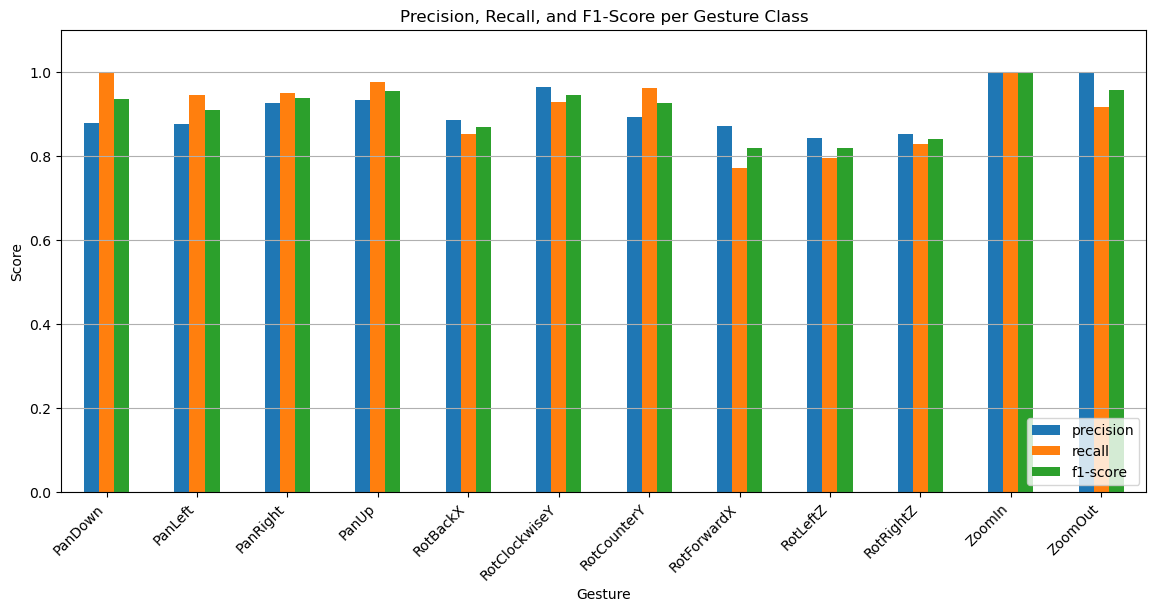

In [285]:
# Plotting precision, recall, and f1-score
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Remove accuracy, macro avg, and weighted avg rows
report_df = report_df.iloc[:-3, :]

# Set up figures
plt.figure(figsize=(12, 6))
ax = report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(14, 6))

# Set x-tick positions and labels correctly
ax.set_xticks(range(len(gesture_label_encoder.classes_)))  # Assign numerical positions
ax.set_xticklabels(gesture_label_encoder.classes_, rotation=45, ha="right")  # Assign class labels

# Modify setup
plt.title("Precision, Recall, and F1-Score per Gesture Class")
plt.xlabel("Gesture")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.legend(loc='lower right')

plt.show()

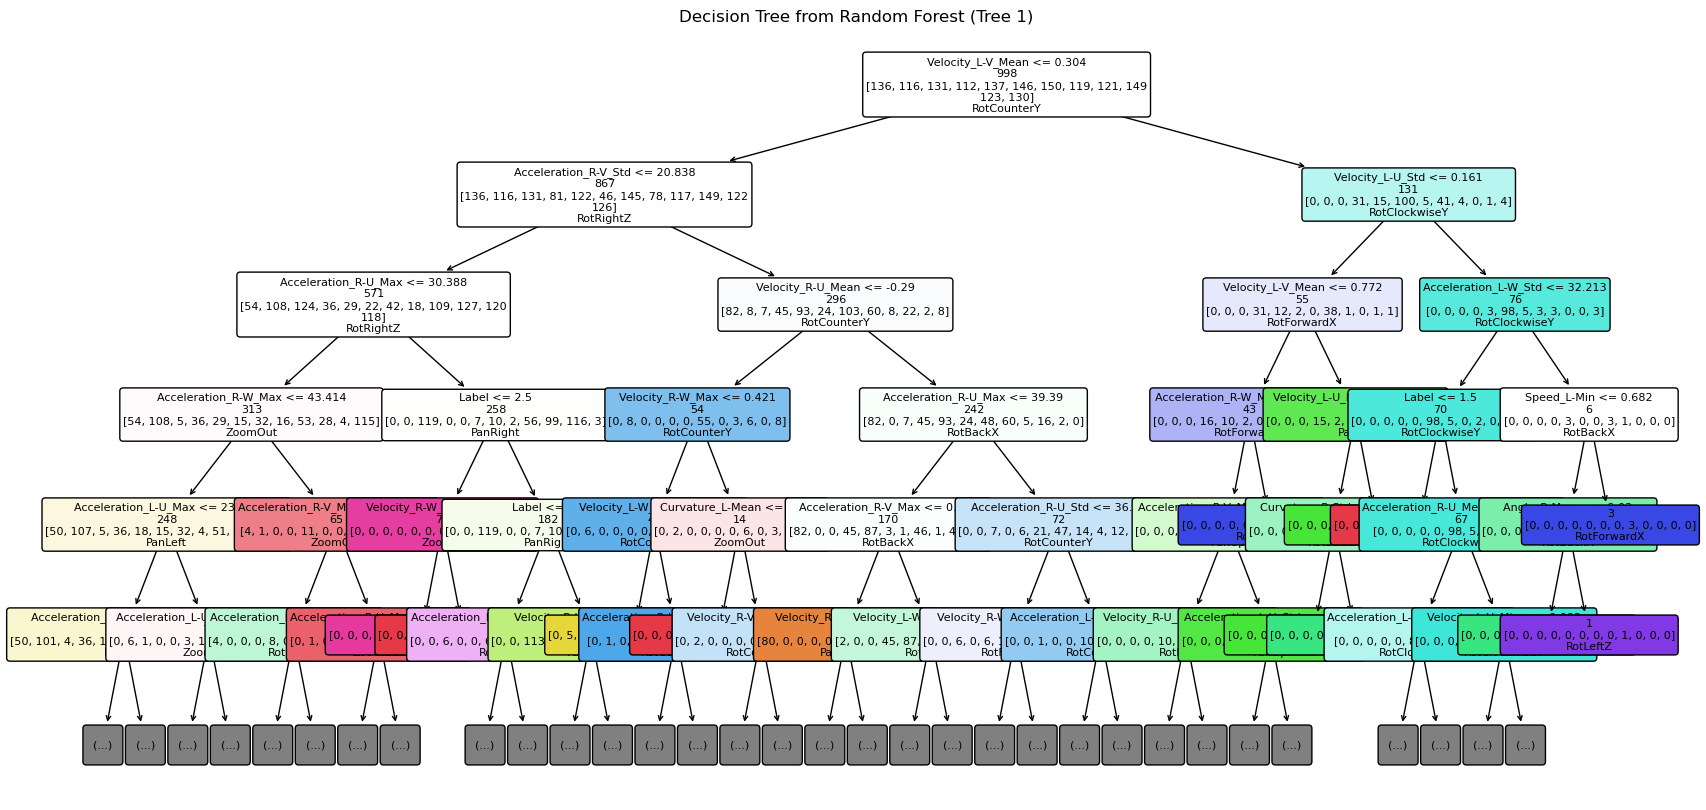

In [44]:
# Plotting a sample bootstrap tree
features = X.columns.tolist()

plt.figure(figsize=(20, 10))
plot_tree(
    rf_model.estimators_[0], 
    feature_names=features,         
    class_names=gesture_label_encoder.classes_.tolist(),
    filled=True,
    rounded=True,
    max_depth=5,
    proportion=False,  # Set to False to avoid proportions inside nodes
    impurity=False,    # Removes Gini values
    label="none",       # Removes feature values
    fontsize=8
)
plt.title("Decision Tree from Random Forest (Tree 1)")
plt.show()


In [84]:
# Displaying list of feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Select the top 40 most important features
top_features_indices = np.argsort(importances)[-40:]  # Indices of top 40 features
top_importances = importances[top_features_indices]   # Their importances
top_feature_names = feature_names[top_features_indices]  # Corresponding feature names

for i in reversed(range(len(top_feature_names))):  # Reverse order (highest importance first)
    print(f"{top_feature_names[i]}: {top_importances[i]:.4f}")

Label: 0.0448
Acceleration_R-U_Min: 0.0336
Acceleration_R-V_Max: 0.0324
Velocity_R-U_Min: 0.0297
Velocity_R-V_Mean: 0.0287
Velocity_R-V_Min: 0.0286
Velocity_R-V_Max: 0.0285
Acceleration_R-V_Mean: 0.0266
Acceleration_R-U_Mean: 0.0262
Acceleration_R-V_Min: 0.0251
Velocity_R-U_Mean: 0.0247
Acceleration_R-U_Max: 0.0240
Acceleration_R-W_Mean: 0.0235
Velocity_R-W_Mean: 0.0234
Velocity_R-U_Max: 0.0220
Velocity_L-U_Mean: 0.0207
Acceleration_L-U_Mean: 0.0203
Acceleration_R-U_Std: 0.0187
Velocity_L-U_Max: 0.0180
Velocity_L-V_Mean: 0.0175
Acceleration_L-U_Max: 0.0169
Acceleration_R-W_Max: 0.0165
Velocity_R-U_Std: 0.0160
Acceleration_R-V_Std: 0.0154
Velocity_R-V_Std: 0.0151
Velocity_R-W_Max: 0.0151
Acceleration_L-V_Mean: 0.0149
Acceleration_L-U_Min: 0.0146
Velocity_L-W_Mean: 0.0146
Acceleration_R-W_Min: 0.0144
Acceleration_L-W_Mean: 0.0143
Velocity_L-U_Min: 0.0140
Acceleration_L-V_Max: 0.0133
Velocity_R-W_Min: 0.0125
Velocity_L-V_Max: 0.0103
Acceleration_L-W_Max: 0.0101
Acceleration_L-V_Min: 0.009

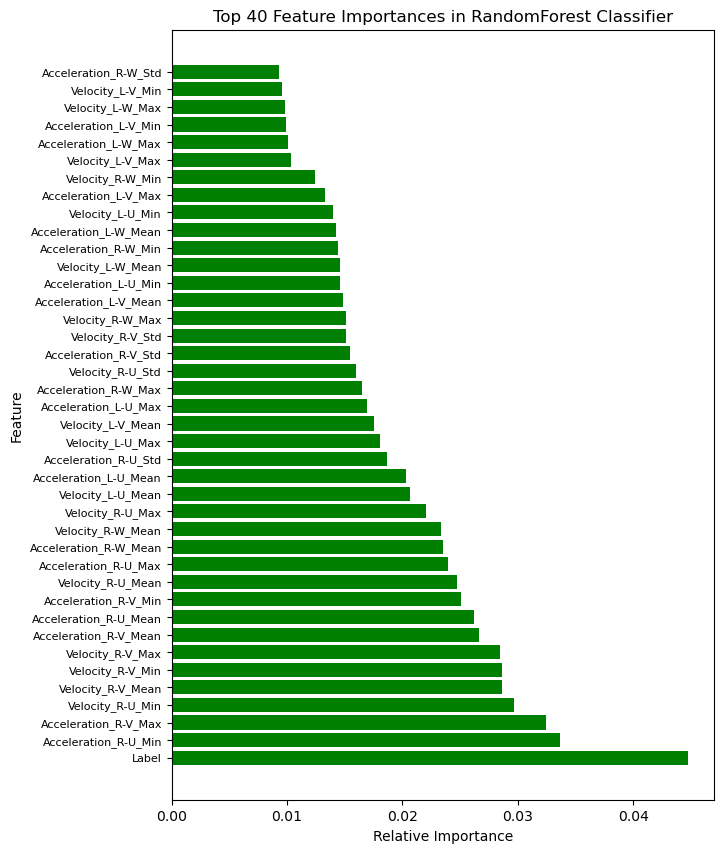

In [85]:
# Plotting only the top 40 feature importances
fig, ax = plt.subplots(figsize=(7, 10))  # Adjust figure size for better readability
ax.barh(range(len(top_importances)), top_importances, color='green')
ax.set_yticks(range(len(top_feature_names)))
ax.set_yticklabels(top_feature_names, fontsize=8)  # Adjust font size for readability
plt.title('Top 40 Feature Importances in RandomForest Classifier')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Flip the order so highest importance is at the top
plt.show()

<Figure size 1000x800 with 0 Axes>

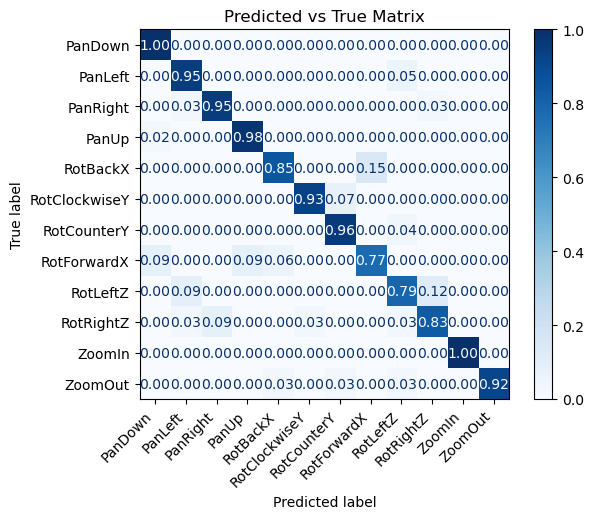

In [286]:
# Confusion matrix to display model predictions against true values
cm = confusion_matrix(y_test, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gesture_label_encoder.classes_)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', values_format='.2f')
plt.xticks(rotation=45, ha="right")
plt.title('Predicted vs True Matrix')
plt.show()

In [87]:
# Identifying trials where the model predicted incorrectly

misclassified_indices = (y_pred != y_test)

misclassified_original_indices = idx_test[misclassified_indices]

# Display Misclassified Rows with Primary Keys
misclassified_df = pd.DataFrame({
    'SubID': data_df.loc[misclassified_original_indices, 'SubID'].values,
    'SessionID': data_df.loc[misclassified_original_indices, 'SessionID'].values,
    'TrialID': data_df.loc[misclassified_original_indices, 'TrialID'].values,
    'Actual Gesture': gesture_label_encoder.inverse_transform(y_test[misclassified_indices]),
    'Predicted Gesture': gesture_label_encoder.inverse_transform(y_pred[misclassified_indices])
})

print(misclassified_df)

    SubID  SessionID  TrialID Actual Gesture Predicted Gesture
0     6.0        2.0      4.0  RotClockwiseY       RotCounterY
1     4.0        2.0      4.0    RotForwardX             PanUp
2    11.0        3.0      4.0       RotBackX       RotForwardX
3     6.0        1.0      4.0  RotClockwiseY       RotCounterY
4    14.0        1.0      3.0       RotLeftZ           PanLeft
5    16.0        2.0      5.0    RotForwardX           PanDown
6    17.0        1.0      2.0        PanLeft          RotLeftZ
7    16.0        1.0      2.0    RotForwardX           PanDown
8    25.0        1.0      3.0    RotForwardX           PanDown
9    19.0        2.0      3.0        ZoomOut       RotCounterY
10   10.0        1.0      3.0       PanRight         RotRightZ
11   22.0        1.0      5.0    RotForwardX             PanUp
12   16.0        2.0      1.0        PanLeft          RotLeftZ
13    4.0        2.0      3.0       RotLeftZ     RotClockwiseY
14   16.0        2.0      2.0       RotLeftZ         Ro

In [287]:
# Make predictions on the validation set
y_validation_pred = rf_model.predict(X_validation)

#print(y_validation_pred)
#print(y_validation)

# Compute validation accuracy
val_accuracy = accuracy_score(y_validation, y_validation_pred)

# Print validation results
print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nValidation Classification Report:\n", classification_report(y_validation, y_validation_pred))

Validation Accuracy: 0.8083

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       0.91      1.00      0.95        10
           2       1.00      0.80      0.89        10
           3       0.91      1.00      0.95        10
           4       0.69      0.90      0.78        10
           5       1.00      0.20      0.33        10
           6       0.62      1.00      0.77        10
           7       1.00      0.50      0.67        10
           8       0.75      0.60      0.67        10
           9       0.62      0.80      0.70        10
          10       0.83      1.00      0.91        10
          11       1.00      0.90      0.95        10

    accuracy                           0.81       120
   macro avg       0.85      0.81      0.79       120
weighted avg       0.85      0.81      0.79       120



In [172]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [118]:
# Define the parameter grid
param_grid = {
    'max_depth': [6, 9, 12],  # Tree depth
    'learning_rate': [0.1, 0.2, 0.3, 0.4],  # Step size shrinkage
    'n_estimators': [200, 250, 300, 350, 400],  # Number of boosting rounds
    'min_child_weight': [1, 5, 10],  # Minimum sum of instance weight
    'subsample': [0.8, 1],  # Fraction of samples per tree
    'colsample_bytree': [0.8, 1],  # Fraction of features per tree
}

xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(y_train.unique()), random_state=42)

# Perform Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(
    xgb_model, 
    param_grid, 
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',  # Optimize for accuracy
    n_jobs=-1,  # Use all CPU cores
    verbose=2  # Print progress
)

# Fit the GridSearch model
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 720 candidates, totalling 2160 fits


KeyboardInterrupt: 

In [ ]:
best_params = grid_search.best_params_

In [288]:
# Set XGBoost parameters
params = {
    'objective': 'multi:softmax',  # For multi-class classification
    'num_class': len(gesture_label_encoder.classes_),  # Number of unique classes
    'eval_metric': ['mlogloss', 'merror'],  # Multi-class log loss
    'max_depth': 8,  # Maximum depth of trees
    'learning_rate': 0.3,  # Step size shrinkage
    'n_estimators': 500,  # Number of boosting rounds
    'reg_alpha': 0.08,
    'reg_lambda': .95,
    'min_child_weight': 1,

    'random_state': 42
}

# Train the model
xgb_model = xgb.XGBClassifier(**params)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['mlogloss', 'merror'],
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_class=12, num_parallel_tree=None, ...)

In [289]:
# Make predictions
y_test_pred = xgb_model.predict(X_test)

# Compute accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nTest Classification Report:\n", classification_report(y_test, y_test_pred))

Test Accuracy: 0.9059

Test Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94        29
           1       0.92      0.92      0.92        37
           2       0.89      0.97      0.93        40
           3       0.93      0.93      0.93        43
           4       0.92      0.85      0.88        27
           5       0.96      0.96      0.96        28
           6       0.96      0.92      0.94        26
           7       0.88      0.80      0.84        35
           8       0.77      0.79      0.78        34
           9       0.85      0.80      0.82        35
          10       0.96      0.96      0.96        23
          11       1.00      0.97      0.99        36

    accuracy                           0.91       393
   macro avg       0.91      0.91      0.91       393
weighted avg       0.91      0.91      0.91       393



In [290]:
# Make predictions on the validation set
y_validation_pred = xgb_model.predict(X_validation)

#print(y_validation_pred)
#print(y_validation)

# Compute validation accuracy
val_accuracy = accuracy_score(y_validation, y_validation_pred)

# Print validation results
print(f"Validation Accuracy: {val_accuracy:.4f}")
print("\nValidation Classification Report:\n", classification_report(y_validation, y_validation_pred))

Validation Accuracy: 0.8417

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      1.00      1.00        10
           2       1.00      0.90      0.95        10
           3       0.91      1.00      0.95        10
           4       0.77      1.00      0.87        10
           5       1.00      0.30      0.46        10
           6       0.67      1.00      0.80        10
           7       1.00      0.60      0.75        10
           8       0.64      0.70      0.67        10
           9       0.55      0.60      0.57        10
          10       1.00      1.00      1.00        10
          11       1.00      1.00      1.00        10

    accuracy                           0.84       120
   macro avg       0.87      0.84      0.83       120
weighted avg       0.87      0.84      0.83       120

